In [5]:
import importlib
import numpy as np
import sys
sys.path.append(r'../src/')

import utils.order_book.order_book_impl as book_utils
import utils.order_book.graphic_utils as graph_utils
import utils.market_maker.quoter as quoter_utils   # adjust path to yours

importlib.reload(book_utils)
importlib.reload(graph_utils)
importlib.reload(quoter_utils)

Order_book    = book_utils.Order_book
Order         = book_utils.Order
generate_id   = book_utils.generate_order_id
Quoter        = quoter_utils.Quoter
QuoterConfig  = quoter_utils.QuoterConfig

In [6]:
from utils.stock_simulation import *
from utils.market_simulator import *

SEED=40
np.random.seed(SEED)
USE_JUMPS = True  # set False to compare pure GARCH(1,1) without jump component
stock_garch = Stock(drift=0.0, vol=0.20)
stock_garch.simulate_garch( n_days=1, dt_seconds=0.01, alpha=0.05, beta=0.94, lam=756 if USE_JUMPS else 0.0, sigma_J=0.005 if USE_JUMPS else 0.0,
)

In [7]:
market_B = Market(stock_garch)
market_B.generate_noised_mid_price()
market_B.build_spread(option="Skew")


market_C = Market(stock_garch)
market_C.generate_noised_mid_price()
market_C.build_spread(option="Skew")

In [8]:
dt = stock_garch.time_step

cfg = QuoterConfig(requote_threshold_spread_fraction=0.25)
market_makerTEST = Quoter(market_B, market_C, config=cfg, capital_K=1_000_000.0)

bookTEST = Order_book()
bookTEST.register_quoter_listener(market_makerTEST.on_fill)  # ← LISTENER WIRED HERE

In [9]:
#test call1
market_makerTEST.compute_quotes(step=1, t=1*dt, resting_orders=bookTEST.mm_resting_orders)

([Quote(direction='buy', price=99.9933, size=np.float64(74081.82), level=1),
  Quote(direction='sell', price=100.0067, size=np.float64(74081.82), level=1),
  Quote(direction='buy', price=99.9932, size=np.float64(54881.16), level=2),
  Quote(direction='sell', price=100.0068, size=np.float64(54881.16), level=2),
  Quote(direction='buy', price=99.9931, size=np.float64(40656.97), level=3),
  Quote(direction='sell', price=100.0069, size=np.float64(40656.97), level=3),
  Quote(direction='buy', price=99.993, size=np.float64(30119.42), level=4),
  Quote(direction='sell', price=100.007, size=np.float64(30119.42), level=4),
  Quote(direction='buy', price=99.9929, size=np.float64(22313.02), level=5),
  Quote(direction='sell', price=100.0071, size=np.float64(22313.02), level=5),
  Quote(direction='buy', price=99.9928, size=np.float64(16529.89), level=6),
  Quote(direction='sell', price=100.0072, size=np.float64(16529.89), level=6),
  Quote(direction='buy', price=99.9927, size=np.float64(12245.64),

In [10]:
#test call2
market_makerTEST.compute_quotes(step=50000, t=50000*dt, resting_orders=bookTEST.mm_resting_orders)

([Quote(direction='buy', price=100.0535, size=np.float64(74081.82), level=1),
  Quote(direction='sell', price=100.067, size=np.float64(74081.82), level=1),
  Quote(direction='buy', price=100.0534, size=np.float64(54881.16), level=2),
  Quote(direction='sell', price=100.0671, size=np.float64(54881.16), level=2),
  Quote(direction='buy', price=100.0533, size=np.float64(40656.97), level=3),
  Quote(direction='sell', price=100.0672, size=np.float64(40656.97), level=3),
  Quote(direction='buy', price=100.0532, size=np.float64(30119.42), level=4),
  Quote(direction='sell', price=100.0673, size=np.float64(30119.42), level=4),
  Quote(direction='buy', price=100.0531, size=np.float64(22313.02), level=5),
  Quote(direction='sell', price=100.0674, size=np.float64(22313.02), level=5),
  Quote(direction='buy', price=100.053, size=np.float64(16529.89), level=6),
  Quote(direction='sell', price=100.0675, size=np.float64(16529.89), level=6),
  Quote(direction='buy', price=100.0529, size=np.float64(122

In [11]:
dt = stock_garch.time_step


cfg = QuoterConfig(requote_threshold_spread_fraction=0.25)
market_A = Quoter(market_B, market_C, config=cfg, capital_K=1_000_000.0)

book = Order_book()
book.register_quoter_listener(market_A.on_fill)  # ← LISTENER WIRED HERE

Quotes generated: 20
ASKS (sell)                                         
----------------------------------------------------
   Lvl         Price            Size
----------------------------------------------------
     1     100.00670        74081.82
     2     100.00680        54881.16
     3     100.00690        40656.97
     4     100.00700        30119.42
     5     100.00710        22313.02
     6     100.00720        16529.89
     7     100.00730        12245.64
     8     100.00740         9071.80
     9     100.00750         6720.55
    10     100.00760         4978.71
                   --- MID ---                  
     1      99.99330        74081.82
     2      99.99320        54881.16
     3      99.99310        40656.97
     4      99.99300        30119.42
     5      99.99290        22313.02
     6      99.99280        16529.89
     7      99.99270        12245.64
     8      99.99260         9071.80
     9      99.99250         6720.55
    10      99.99240         49

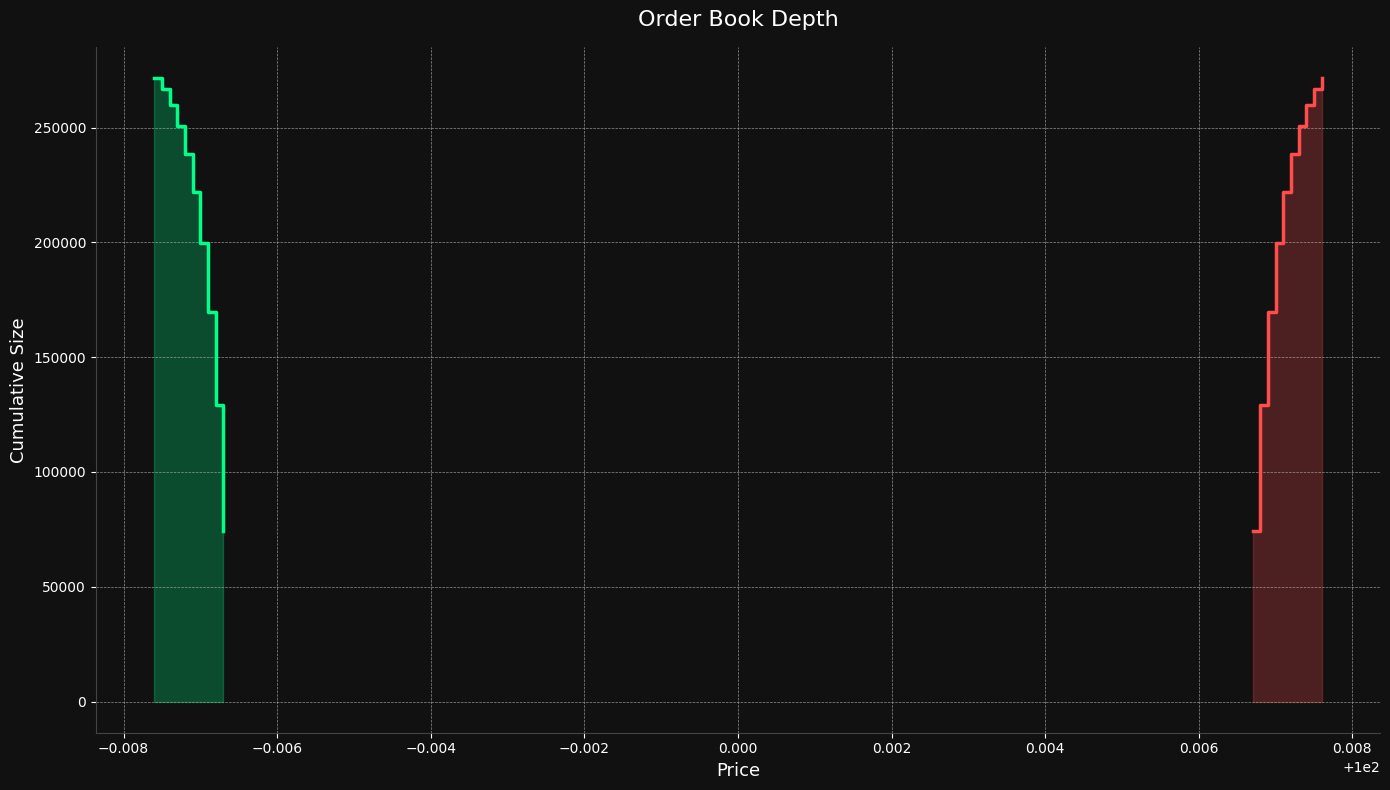

In [12]:
step = 1
quotes, cancels = market_A.compute_quotes(step=step, t=step*dt,
                                           resting_orders=book.mm_resting_orders)
print(f"Quotes generated: {len(quotes)}")

for q in quotes:
    book.add_order(Order(generate_id(), q.direction, q.price, q.size,
                         "limit_order", "market_maker", q.level))

book.display_mm_quotes()
graph_utils.plot_order_book(book)

In [15]:
step = 5000
book.tick(step)

client_orders = book.generate_random_orders(10, origin="client")
for c in client_orders:
    book.submit_client_order(c)   # ← each call: _try_clear() → _fire_fill() → market_A.on_fill()

print(f"Matches so far: {len(book._df_matches)}")
print(f"Inventory after fills: {market_A.inventory:+.2f} EUR")
print(f"Fill history: {len(market_A._fill_history)} fills")
book._df_matches[["Direction", "Price", "MatchedSize", "ClientOrderId", "MmOrderId"]]

Matches so far: 5
Inventory after fills: +0.00 EUR
Fill history: 0 fills


,Direction,Price,MatchedSize,ClientOrderId,MmOrderId
0,sell,99.9933,2098.0,1776281367107_7155,1776281366293_7647
1,buy,100.0067,2048.0,1776281367193_5796,1776281366359_1794
2,buy,100.0294,2027.0,1776281432145_4360,1776281367412_9638
3,buy,100.0294,1875.0,1776281432152_0743,1776281367412_9638
4,sell,100.0160,1872.0,1776281432174_8436,1776281367409_4992


Cancels: 0  |  New quotes: 0
ASKS (sell)                                         
----------------------------------------------------
   Lvl         Price            Size
----------------------------------------------------
     1     100.02940        70179.82
     2     100.02950        54881.16
     3     100.02960        40656.97
     4     100.02970        30119.42
     5     100.02980        22313.02
     6     100.02990        16529.89
     7     100.03000        12245.64
     8     100.03010         9071.80
     9     100.03020         6720.55
    10     100.03030         4978.71
                   --- MID ---                  
     1     100.01600        72209.82
     2     100.01590        54881.16
     3     100.01580        40656.97
     4     100.01570        30119.42
     5     100.01560        22313.02
     6     100.01550        16529.89
     7     100.01540        12245.64
     8     100.01530         9071.80
     9     100.01520         6720.55
    10     100.01510   

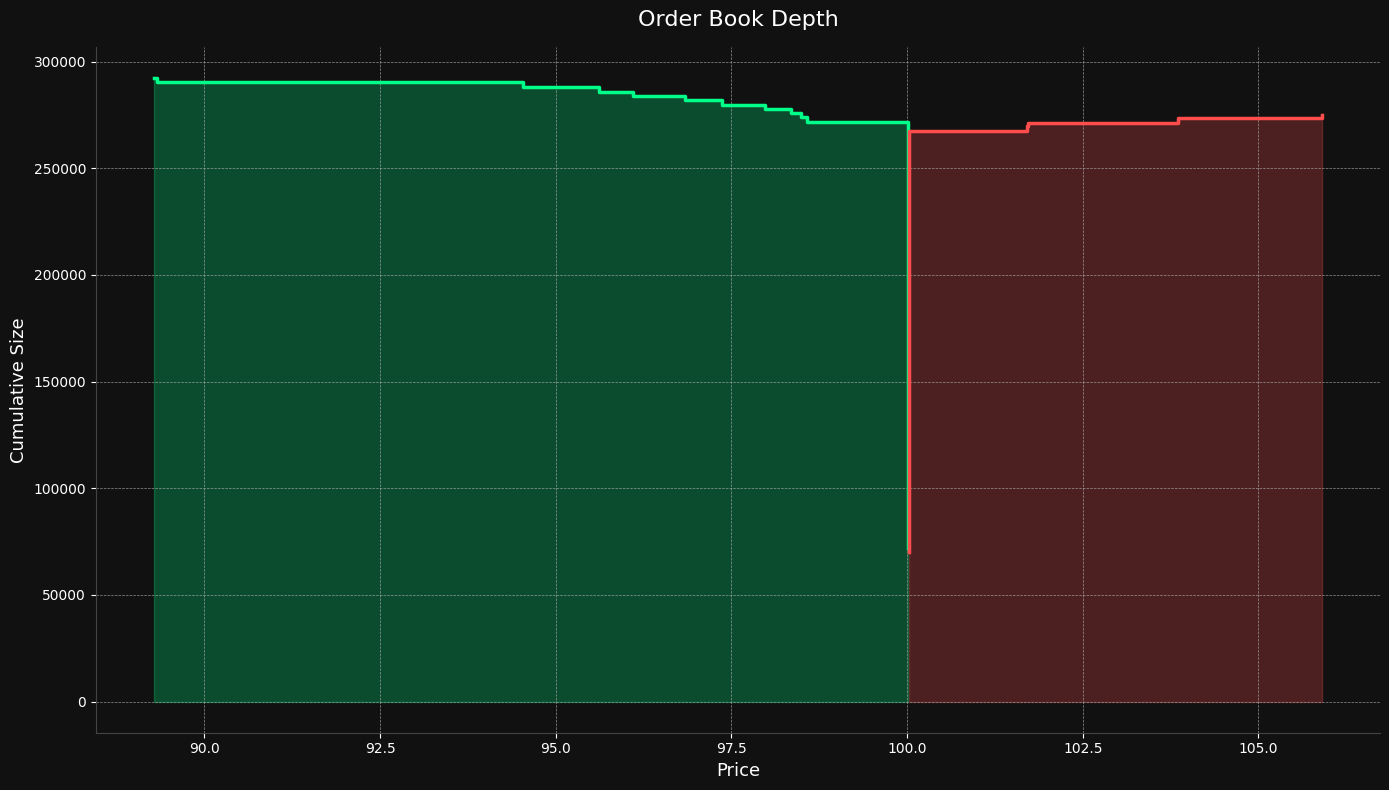

In [16]:
quotes, cancels = market_A.compute_quotes(step=step, t=step*dt,
                                           resting_orders=book.mm_resting_orders)
print(f"Cancels: {len(cancels)}  |  New quotes: {len(quotes)}")

book.cancel_orders(cancels)
for q in quotes:
    book.add_order(Order(generate_id(), q.direction, q.price, q.size,
                         "limit_order", "market_maker", q.level))

book.display_mm_quotes()
graph_utils.plot_order_book(book)